Get only data up until 2025

In [95]:
import pandas as pd
import os
import sys

# Add the parent directory to the Python path to import from data.export
sys.path.append(os.path.abspath(".."))

df_2025_class = df_2025 = pd.read_csv("export/classification_data_2025.csv")

# duplicate study_id 4523 from merging 
df_2025_class = df_2025_class[df_2025_class['study_id'] != 4523]

len(df_2025_class['study_id'].unique()) 

3946

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


def plot_task_grouped_bar(df: pd.DataFrame, x_task: str, group_task: str, exclude_labels: dict = None, figsize=(12, 6), title: str | None = None) -> pd.DataFrame:
    """
    Create a grouped bar plot from a classification DataFrame.

    Parameters:
    - df: DataFrame containing columns `study_id`, `task`, `label`.
    - x_task: task name to use for the x-axis categories (e.g., 'Substances').
    - group_task: task name to use for grouping/hue (e.g., 'Condition').
    - exclude_labels: optional dict mapping task -> list of labels to exclude.
    - figsize: figure size tuple.
    - title: optional title string.

    Returns:
    - counts DataFrame with columns [x, group, n_studies].
    """
    data = df.copy()

    # Apply exclusions if provided
    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    # Select rows for each task and rename label columns for merge
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})
    right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})

    # Merge on study_id and count occurrences
    merged = pd.merge(left, right, on="study_id")
    counts = merged.groupby(["x", "group"]).size().reset_index(name="n_studies")

    # Plot 
    plt.figure(figsize=figsize)
    sns.barplot(data=counts, x="x", y="n_studies", hue="group")
    plt.title(title or f"{x_task} by {group_task}")
    plt.xlabel(x_task)
    plt.ylabel("Number of studies")
    plt.xticks(rotation=45)
    plt.legend(title=group_task, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return counts


def plot_task_stacked_bar(
    df: pd.DataFrame,
    x_task: str,
    group_task: str,
    exclude_labels: dict | None = None,
    merge_labels: dict | None = None,
    value_name: str = "n_studies",
    figsize=(12, 12),
):
    """
    Create a stacked bar plot where each x-category (e.g. substance) is stacked by groups (e.g. conditions).

    Parameters:
    - df: DataFrame with columns `study_id`, `task`, `label` (or additional group column).
    - x_task: task name to use for x-axis categories (rows where `task==x_task` and `label` becomes x).
    - group_task: task name to use for stacking (rows where `task==group_task` and `label` becomes group),
                  or an existing column name in `df` to use directly as group.
    - exclude_labels: optional dict mapping task -> list of labels to exclude before plotting.
    - value_name: name for the aggregated count column.
    - figsize: figure size.

    Returns the counts DataFrame used for plotting.
    """
    data = df.copy()

    # Apply exclusions (task -> list[label])
    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    if merge_labels:
        for task_name, mapping in merge_labels.items():
            for new_label, old_labels in mapping.items():
                mask = (data["task"] == task_name) & (data["label"].isin(old_labels))
                data.loc[mask, "label"] = new_label

    total_nr_studies_per_x = {}
    task_filtered = data[data['task'] == x_task]

    for label in task_filtered['label'].unique():
        # filter according to label
        df_filtered = task_filtered[task_filtered['label'] == label]
        total_nr_studies_per_x[label] = len(df_filtered['study_id'].unique())
    

    # Build left (x) dataframe from x_task
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})

    # Build right (group) dataframe either from task rows or from an existing column
    if group_task in data["task"].unique():
        right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})
    elif group_task in data.columns:
        right = data[["study_id", group_task]].rename(columns={group_task: "group"})
    else:
        raise ValueError(f"group_task '{group_task}' not found as a task or column in the dataframe")

    # Merge on study_id and count occurrences
    merged = pd.merge(left, right, on="study_id")
    counts = (
        merged.groupby(["x", "group"])["study_id"]
        .nunique()
        .reset_index(name=value_name)
    )

    # Pivot for stacked plotting
    pivot = counts.pivot_table(index="x", columns="group", values=value_name, fill_value=0)

    # order by total frequency
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Color palette
    groups = pivot.columns.tolist()
    colors = plt.cm.get_cmap("tab20", len(groups))
    color_map = {g: colors(i) for i, g in enumerate(groups)}

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    result_rows = []

    for i, x_val in enumerate(pivot.index):
        row = pivot.loc[x_val]
        sorted_row = row.sort_values(ascending=False)

        bottom = 0
        total = total_nr_studies_per_x[x_val]

        for grp, val in sorted_row.items():
            if val == 0:
                continue

            pct = (val / total) * 100
            result_rows.append({
                "x": x_val,
                "group": grp,
                "count": int(val),
                "total": int(total),
                "percentage": pct,
            })

            ax.bar(
                x_val,
                val,
                bottom=bottom,
                color=color_map[grp],
                label=grp if i == 0 else "",
            )

            ax.text(
                x_val,
                bottom + val / 2,
                f"{int(val)}\n({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=7,
            )

            bottom += val

        ax.text(
            x_val,
            bottom + bottom * 0.02, 
            f"n={int(total)}",
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
        )

    # Legend cleanup
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title=group_task, bbox_to_anchor=(1.05, 1), loc="upper left")

    # Formatting
    ax.set_title(f"{group_task} across {x_task}")
    ax.set_xlabel(x_task)
    ax.set_ylabel("Count")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(result_rows)


def plot_task_stacked_bar_interactive(
    df: pd.DataFrame,
    x_task: str,
    group_task: str,
    exclude_labels: dict | None = None,
    merge_labels: dict | None = None,
    value_name: str = "n_studies",
):
    data = df.copy()

    if exclude_labels:
        for task_name, labels in exclude_labels.items():
            data = data[~((data["task"] == task_name) & (data["label"].isin(labels)))]

    if merge_labels:
        for task_name, mapping in merge_labels.items():
            for new_label, old_labels in mapping.items():
                mask = (data["task"] == task_name) & (data["label"].isin(old_labels))
                data.loc[mask, "label"] = new_label

    # Total studies per x
    task_filtered = data[data["task"] == x_task]
    total_nr_studies_per_x = (
        task_filtered.groupby("label")["study_id"]
        .nunique()
        .to_dict()
    )

    # Build left/right
    left = data[data["task"] == x_task][["study_id", "label"]].rename(columns={"label": "x"})

    if group_task in data["task"].unique():
        right = data[data["task"] == group_task][["study_id", "label"]].rename(columns={"label": "group"})
    elif group_task in data.columns:
        right = data[["study_id", group_task]].rename(columns={group_task: "group"})
    else:
        raise ValueError(f"group_task '{group_task}' not found")

    merged = pd.merge(left, right, on="study_id")

    counts = merged.groupby(["x", "group"]).size().reset_index(name=value_name)

    # Pivot
    pivot = counts.pivot_table(index="x", columns="group", values=value_name, fill_value=0)

    # Sort x by total
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Build result dataframe
    result_rows = []
    for x_val in pivot.index:
        total = total_nr_studies_per_x[x_val]
        for grp in pivot.columns:
            val = pivot.loc[x_val, grp]
            if val == 0:
                continue
            pct = (val / total) * 100
            result_rows.append({
                "x": x_val,
                "group": grp,
                "count": int(val),
                "total": int(total),
                "percentage": pct,
            })

    result_df = pd.DataFrame(result_rows)

    fig = go.Figure()

    unique_groups = list(pivot.columns)
    color_palette = px.colors.qualitative.Plotly
    color_map = {
        grp: color_palette[i % len(color_palette)]
        for i, grp in enumerate(unique_groups)
    }

    shown_groups = set()

    for x_val in pivot.index:
        row = pivot.loc[x_val]

        sorted_groups = row.sort_values(ascending=False)

        total = total_nr_studies_per_x[x_val]

        for grp, val in sorted_groups.items():
            if val == 0:
                continue

            pct = (val / total) * 100

            fig.add_trace(go.Bar(
                name=grp,
                x=[x_val],
                y=[val],
                marker=dict(color=color_map[grp]),
                customdata=[pct],
                hovertemplate=(
                    "<b>%{x}</b><br>"
                    f"{grp}<br>"
                    "Count: %{y}<br>"
                    "Percentage: %{customdata:.1f}%<extra></extra>"
                ),
                showlegend=grp not in shown_groups
            ))

            shown_groups.add(grp)

    fig.update_layout(
        barmode="stack",
        title=f"{group_task} across {x_task}",
        xaxis_title=x_task,
        yaxis_title="Count",
        xaxis_tickangle=-45,
        legend_title=group_task,
        height=700,
    )

    fig.show()

    return result_df


## Substances-Condition Analysis

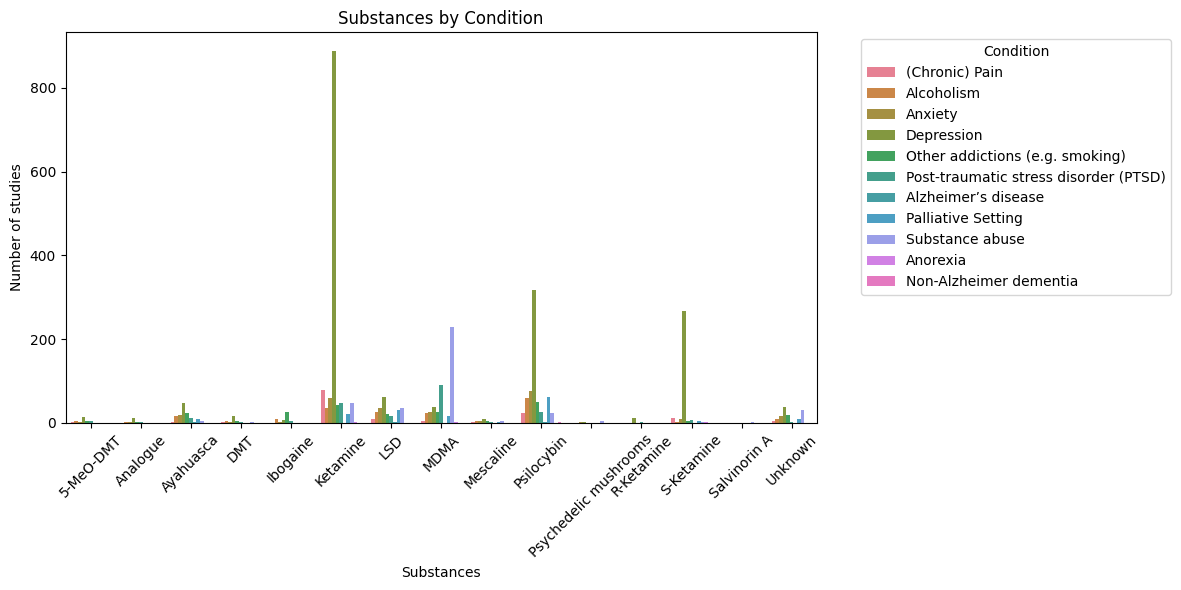

,x,group,n_studies
0,5-MeO-DMT,(Chronic) Pain,1
1,5-MeO-DMT,Alcoholism,5
2,5-MeO-DMT,Anxiety,3
3,5-MeO-DMT,Depression,15
4,5-MeO-DMT,Other addictions (e.g. smoking),4


In [97]:
# Example usage (uncomment to run):
counts = plot_task_grouped_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy"]
    }
)
counts.head()

## X: Substances, Y: Count of Studies, Segments: Conditions

In [119]:
counts = plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy", 'Ketamine']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



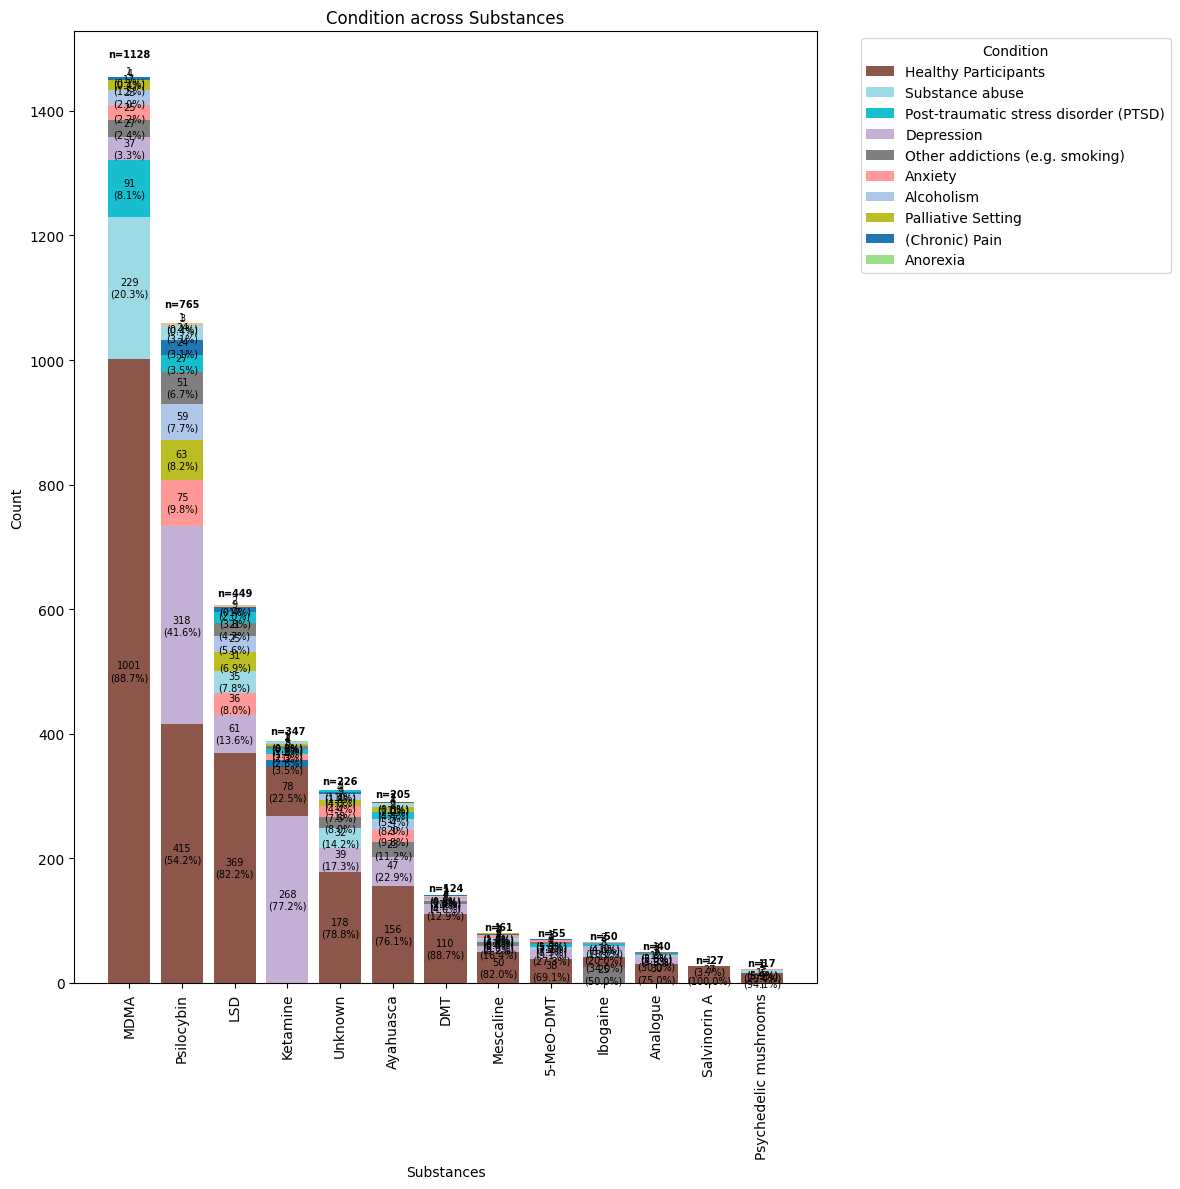

In [ ]:
plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use"],
        "Substances": ["Combination Therapy", "Ketamine", ]
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

In [122]:
plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Condition",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use"],
        "Substances": ["Combination Therapy"]
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "R-Ketamine", "S-Ketamine"]
        }
    }
)

,x,group,count,total,percentage
0,Ketamine,(Chronic) Pain,90,1590,5.660377
1,Ketamine,Alcoholism,37,1590,2.327044
2,Ketamine,Anorexia,2,1590,0.125786
3,Ketamine,Anxiety,68,1590,4.276730
4,Ketamine,Depression,1165,1590,73.270440
...,...,...,...,...,...
97,Salvinorin A,Substance abuse,1,27,3.703704
98,Psychedelic mushrooms,Anxiety,1,17,5.882353
99,Psychedelic mushrooms,Depression,1,17,5.882353
100,Psychedelic mushrooms,Healthy Participants,16,17,94.117647


## X: Condition, Y: Count of Studies, Segments: Substances

/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



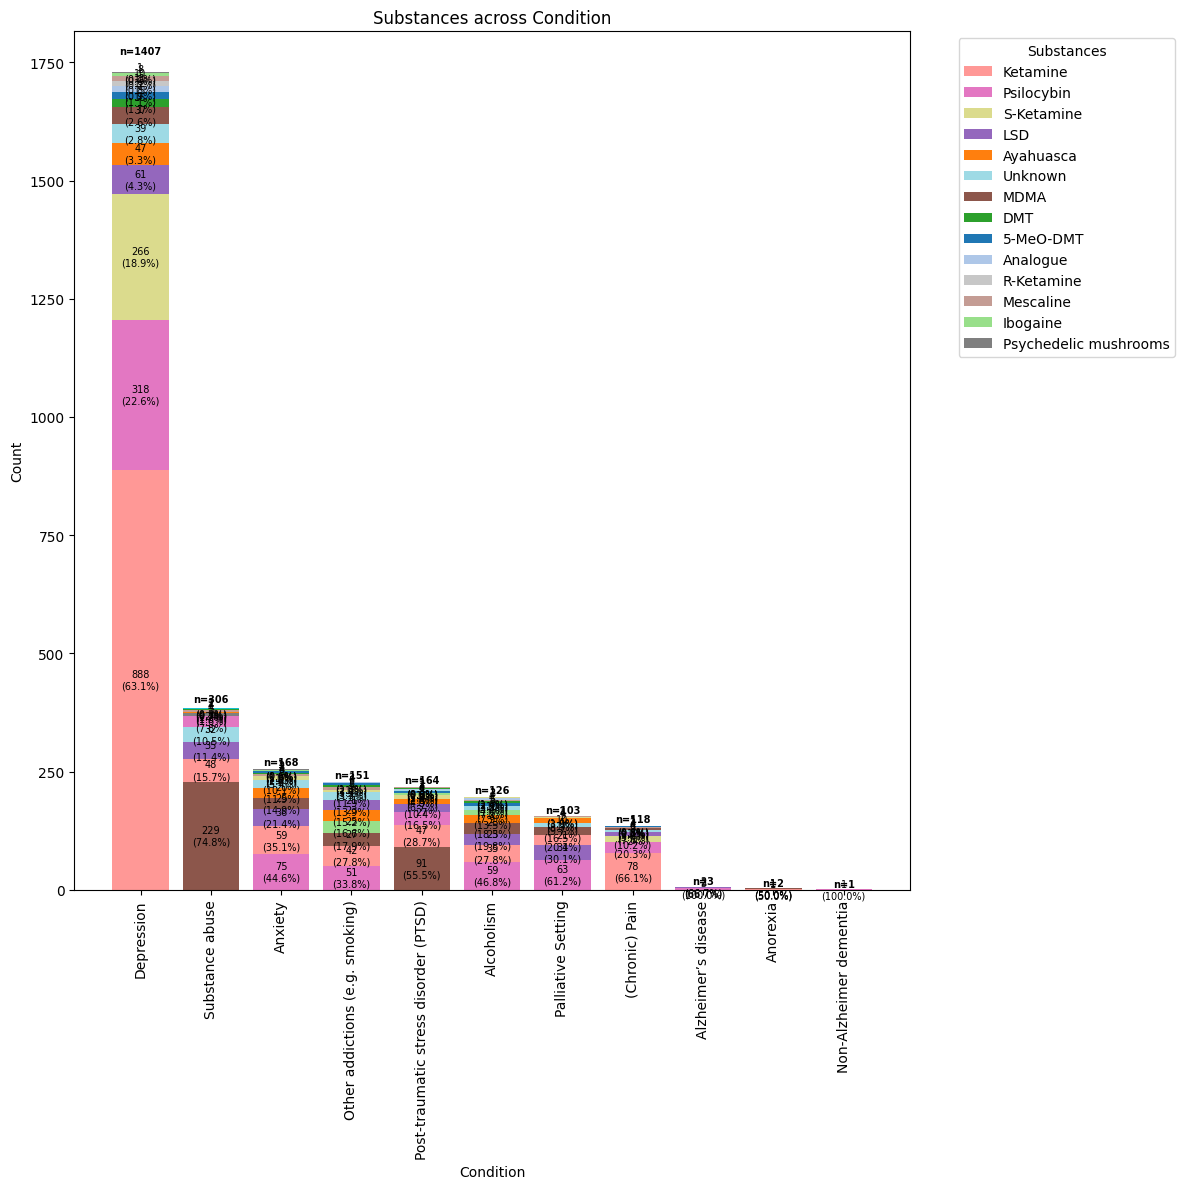

In [100]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Condition",
    group_task="Substances",
    exclude_labels={
        "Condition": ["Psychiatric condition", "Recreational Drug Use", "Healthy Participants"],
        "Substances": ["Combination Therapy"]
    },
)

# Study Type - Substances
## X: Substances, Y: Count of Studies, Segments: Study Type

/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



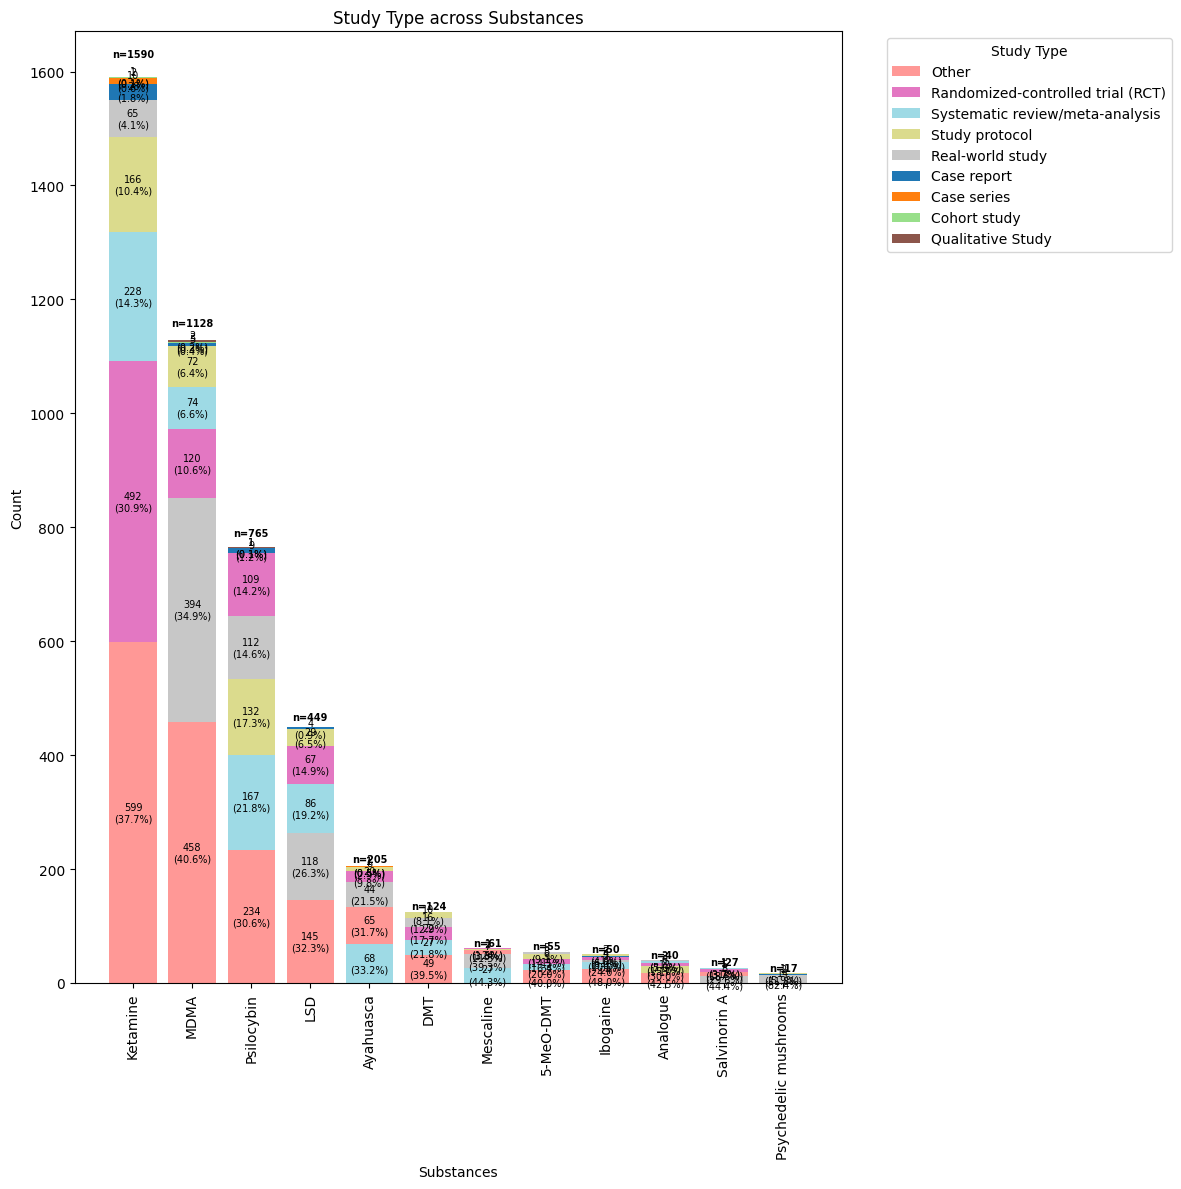

In [101]:
pct_sub_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Type",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"],
        # "Study Type": ["Other"]
    },
        merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [102]:
plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Study Type",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"],
        # "Study Type": ["Other"]
    },
        merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)

,x,group,count,total,percentage
0,Ketamine,Case report,30,1590,1.886792
1,Ketamine,Case series,12,1590,0.754717
2,Ketamine,Cohort study,2,1590,0.125786
3,Ketamine,Other,649,1590,40.817610
4,Ketamine,Qualitative Study,1,1590,0.062893
...,...,...,...,...,...
67,Salvinorin A,Study protocol,1,27,3.703704
68,Salvinorin A,Systematic review/meta-analysis,1,27,3.703704
69,Psychedelic mushrooms,Case report,2,17,11.764706
70,Psychedelic mushrooms,Real-world study,14,17,82.352941


What substance has the highest number/proportion of Randomized Controlled Trials (RCTs)?

In [103]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Randomized-controlled trial (RCT)"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    492   1590   30.943396
66  Salvinorin A  Randomized-controlled trial (RCT)      5     27   18.518519
40           DMT  Randomized-controlled trial (RCT)     22    124   17.741935
50     5-MeO-DMT  Randomized-controlled trial (RCT)      9     55   16.363636
61      Analogue  Randomized-controlled trial (RCT)      6     40   15.000000
28           LSD  Randomized-controlled trial (RCT)     67    449   14.922049
21    Psilocybin  Randomized-controlled trial (RCT)    109    765   14.248366
11          MDMA  Randomized-controlled trial (RCT)    120   1128   10.638298
34     Ayahuasca  Randomized-controlled trial (RCT)     20    205    9.756098
56      Ibogaine  Randomized-controlled trial (RCT)      4     50    8.000000
47     Mescaline  Randomized-controlled trial (RCT)      1     61    1.639344


In [104]:
rct_sorted = rct_df.sort_values(by="count", ascending=False)
print(rct_sorted)


               x                              group  count  total  percentage
1       Ketamine  Randomized-controlled trial (RCT)    492   1590   30.943396
11          MDMA  Randomized-controlled trial (RCT)    120   1128   10.638298
21    Psilocybin  Randomized-controlled trial (RCT)    109    765   14.248366
28           LSD  Randomized-controlled trial (RCT)     67    449   14.922049
40           DMT  Randomized-controlled trial (RCT)     22    124   17.741935
34     Ayahuasca  Randomized-controlled trial (RCT)     20    205    9.756098
50     5-MeO-DMT  Randomized-controlled trial (RCT)      9     55   16.363636
61      Analogue  Randomized-controlled trial (RCT)      6     40   15.000000
66  Salvinorin A  Randomized-controlled trial (RCT)      5     27   18.518519
56      Ibogaine  Randomized-controlled trial (RCT)      4     50    8.000000
47     Mescaline  Randomized-controlled trial (RCT)      1     61    1.639344


Which substances have the highest number/proportion of Real-World Studies?

In [105]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Real-world study"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x             group  count  total  percentage
69  Psychedelic mushrooms  Real-world study     14     17   82.352941
64           Salvinorin A  Real-world study     12     27   44.444444
44              Mescaline  Real-world study     24     61   39.344262
10                   MDMA  Real-world study    394   1128   34.929078
26                    LSD  Real-world study    118    449   26.280624
33              Ayahuasca  Real-world study     44    205   21.463415
20             Psilocybin  Real-world study    112    765   14.640523
41                    DMT  Real-world study     16    124   12.903226
55               Ibogaine  Real-world study      5     50   10.000000
52              5-MeO-DMT  Real-world study      5     55    9.090909
63               Analogue  Real-world study      2     40    5.000000
4                Ketamine  Real-world study     65   1590    4.088050


In [ ]:
rct_sorted = rct_df.sort_values(by="count", ascending=False)
print(rct_sorted)

Which substances have the highest number/proportion of case reports for each condition?

In [106]:
rct_df = pct_sub_study_type[pct_sub_study_type["group"] == "Case report"]

rct_sorted = rct_df.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x        group  count  total  percentage
70  Psychedelic mushrooms  Case report      2     17   11.764706
57               Ibogaine  Case report      3     50    6.000000
5                Ketamine  Case report     28   1590    1.761006
22             Psilocybin  Case report      9    765    1.176471
30                    LSD  Case report      4    449    0.890869
14                   MDMA  Case report      5   1128    0.443262


## X: Study Type, Y: Count of Studies, Segments: Substances

/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



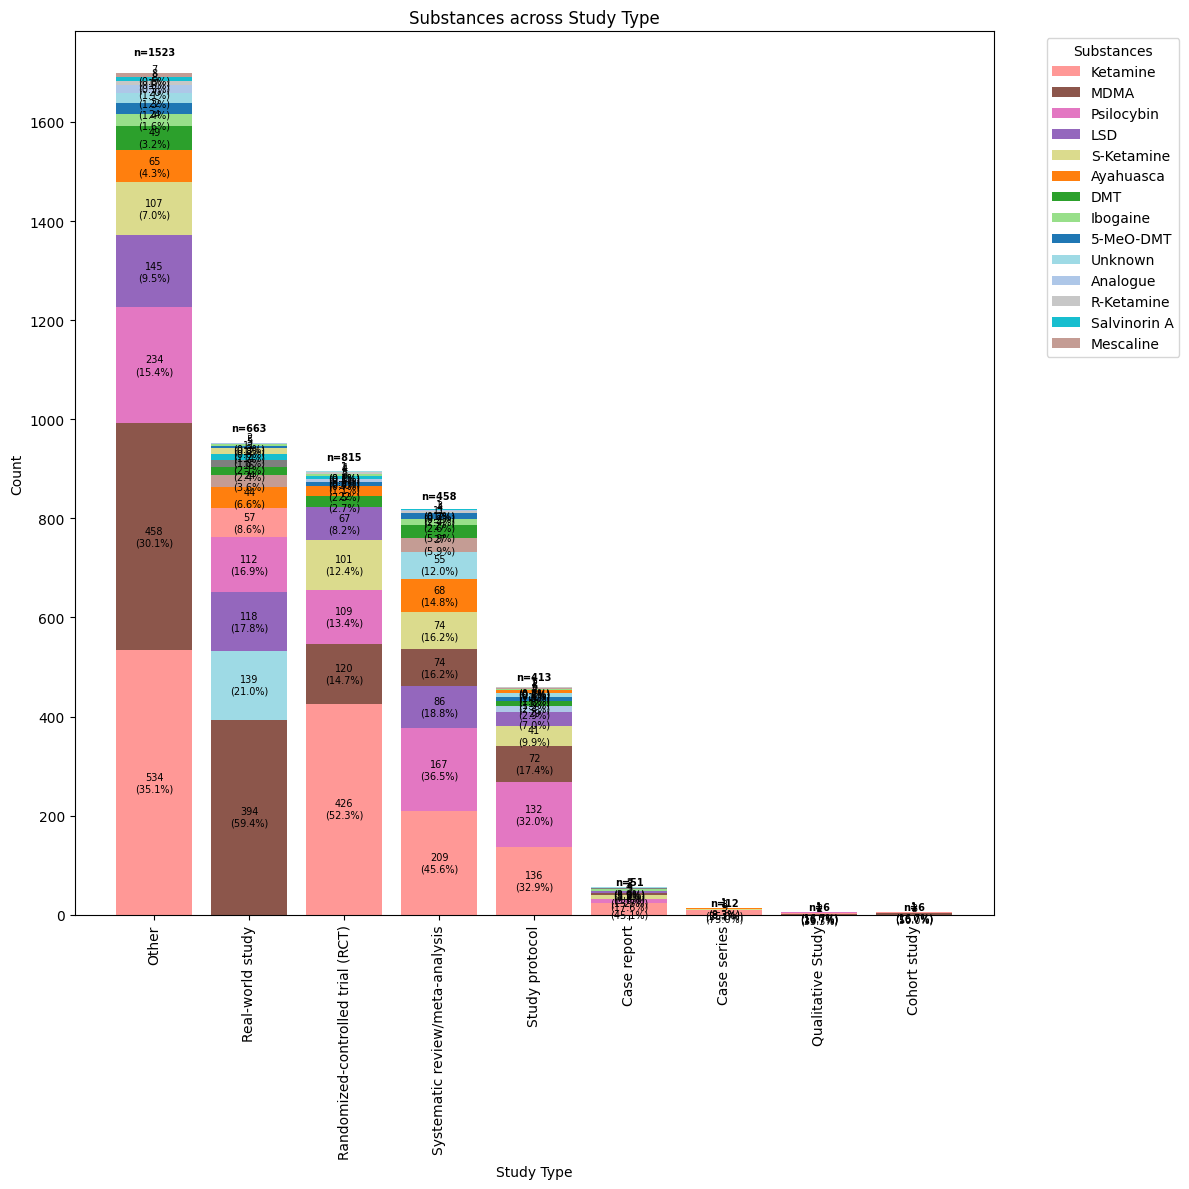

In [107]:
pct_study_type = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Type",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy"]
    }
)



/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



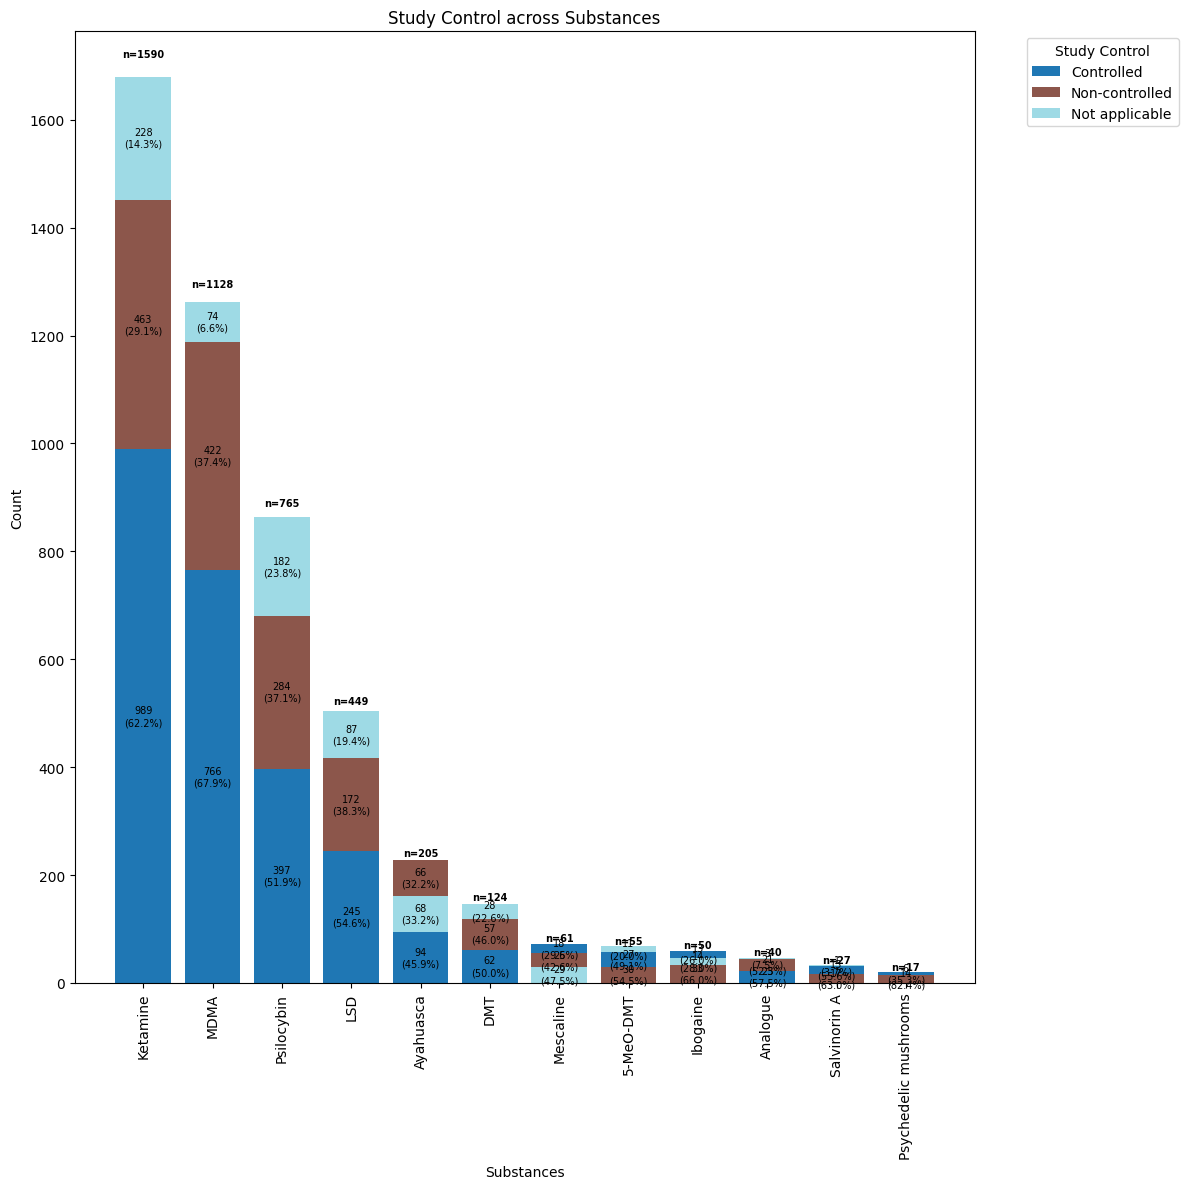

In [128]:
pct_control = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Control",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    },
    merge_labels={
        'Study Control': {
            'Controlled': ['Placebo', 'Other control', 'Active control']
        },
        'Substances': {
            'Ketamine': ['Ketamine', 'R-Ketamine', 'S-Ketamine']
        }
    }
)

In [127]:
control = pct_control[pct_control["group"] == "Controlled"]
rct_sorted = control.sort_values(by="percentage", ascending=False)
print(rct_sorted)

                        x       group  count  total  percentage
3                    MDMA  Controlled    766   1128   67.907801
0                Ketamine  Controlled    861   1395   61.720430
12             S-Ketamine  Controlled    209    345   60.579710
30               Analogue  Controlled     23     40   57.500000
34           Salvinorin A  Controlled     15     27   55.555556
9                     LSD  Controlled    245    449   54.565702
6              Psilocybin  Controlled    397    765   51.895425
18                    DMT  Controlled     62    124   50.000000
25              5-MeO-DMT  Controlled     27     55   49.090909
38             R-Ketamine  Controlled      8     17   47.058824
15              Ayahuasca  Controlled     94    205   45.853659
37  Psychedelic mushrooms  Controlled      6     17   35.294118
23              Mescaline  Controlled     18     61   29.508197
29               Ibogaine  Controlled     13     50   26.000000


In [131]:
uncontrol = pct_control[pct_control["group"] == "Non-controlled"]
controlled = uncontrol.sort_values(by="percentage", ascending=False)
print(controlled)

                        x           group  count  total  percentage
33  Psychedelic mushrooms  Non-controlled     14     17   82.352941
24               Ibogaine  Non-controlled     33     50   66.000000
30           Salvinorin A  Non-controlled     17     27   62.962963
21              5-MeO-DMT  Non-controlled     30     55   54.545455
28               Analogue  Non-controlled     21     40   52.500000
16                    DMT  Non-controlled     57    124   45.967742
19              Mescaline  Non-controlled     26     61   42.622951
10                    LSD  Non-controlled    172    449   38.307350
4                    MDMA  Non-controlled    422   1128   37.411348
7              Psilocybin  Non-controlled    284    765   37.124183
14              Ayahuasca  Non-controlled     66    205   32.195122
1                Ketamine  Non-controlled    463   1590   29.119497


/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



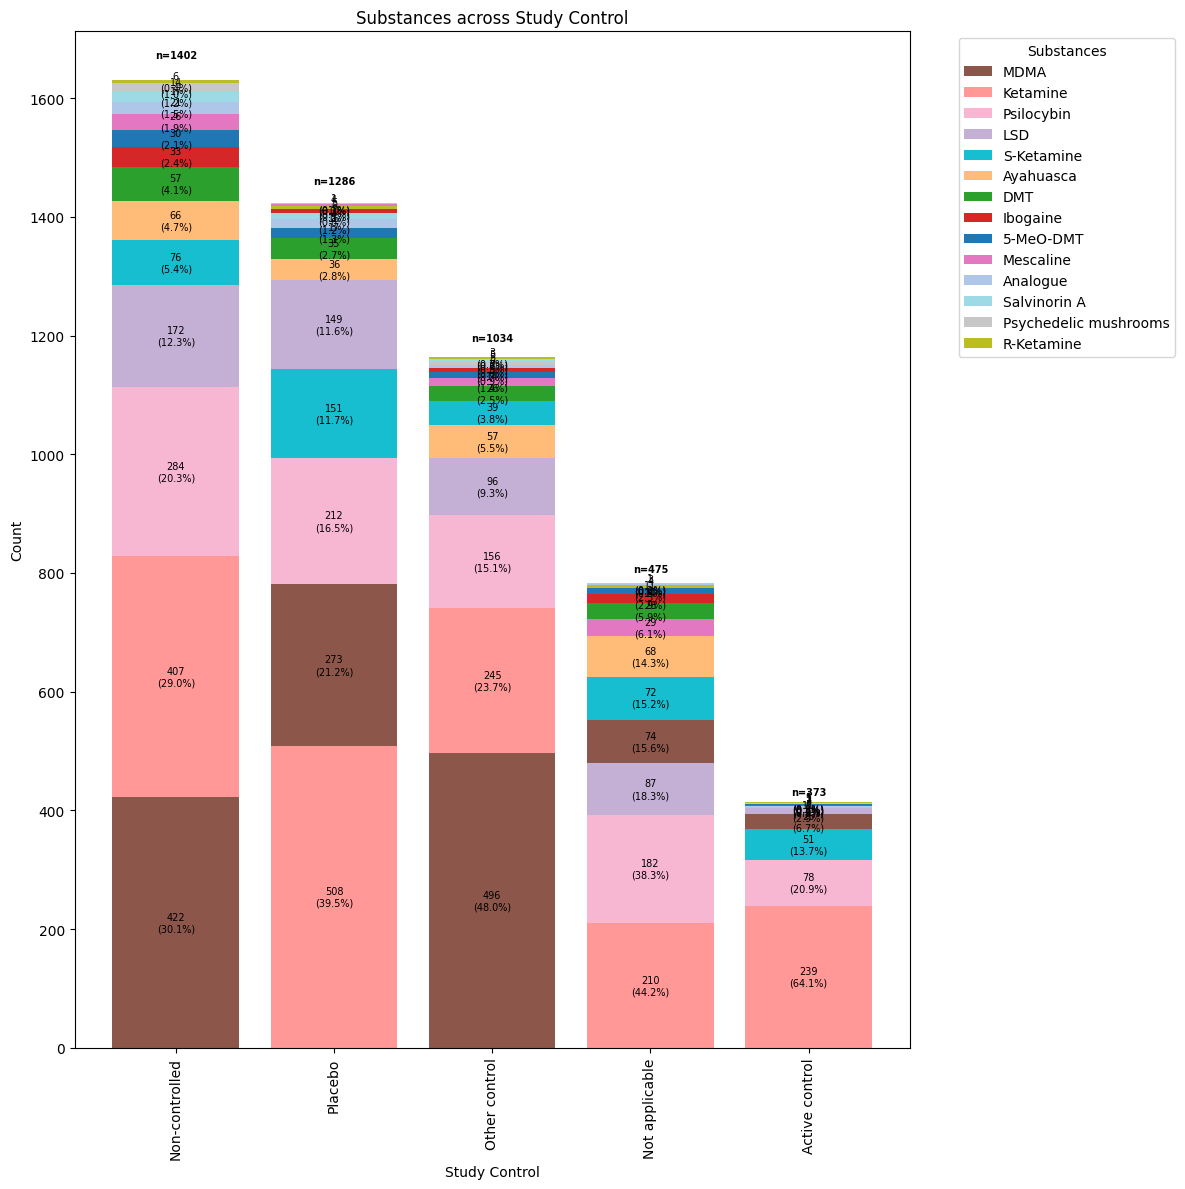

In [110]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Control",
    group_task="Substances",
    exclude_labels={   
        "Substances": ["Combination Therapy", "Unknown"]
    }
)

# Study Purpose

/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



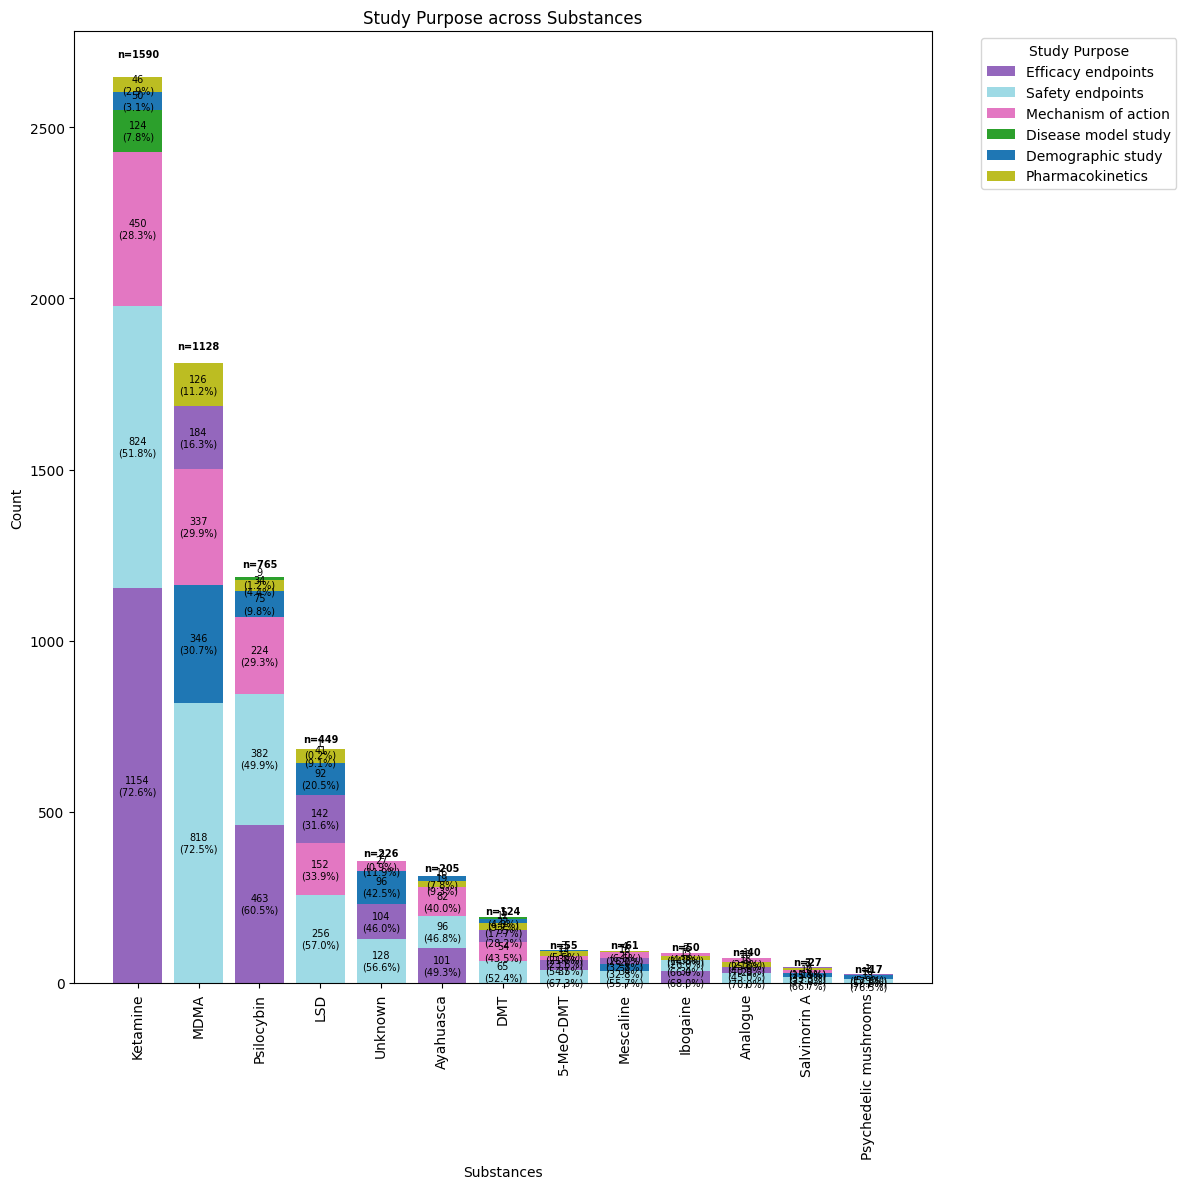

In [111]:
study_purpose = plot_task_stacked_bar(
    df_2025_class,
    x_task="Substances",
    group_task="Study Purpose",
    exclude_labels={
        "Substances": ['Other', 'Unkown', 'Combination Therapy']
    },
    merge_labels={
        "Substances": {
            "Ketamine": ["Ketamine", "S-Ketamine", "R-Ketamine"]
        }
    }
)


In [112]:
sp_df = study_purpose[study_purpose["group"] == "Mechanism of action"]

sp_sorted = sp_df.sort_values(by="percentage", ascending=False)
print(sp_sorted)

                        x                group  count  total  percentage
34                    DMT  Mechanism of action     54    124   43.548387
30              Ayahuasca  Mechanism of action     82    205   40.000000
18                    LSD  Mechanism of action    152    449   33.853007
61           Salvinorin A  Mechanism of action      9     27   33.333333
8                    MDMA  Mechanism of action    337   1128   29.875887
13             Psilocybin  Mechanism of action    224    765   29.281046
2                Ketamine  Mechanism of action    450   1590   28.301887
47              Mescaline  Mechanism of action     16     61   26.229508
57               Analogue  Mechanism of action     10     40   25.000000
41              5-MeO-DMT  Mechanism of action     13     55   23.636364
52               Ibogaine  Mechanism of action      7     50   14.000000
26                Unknown  Mechanism of action     27    226   11.946903
67  Psychedelic mushrooms  Mechanism of action     

In [113]:
sp_df = study_purpose[study_purpose["group"] == "Demographic study"]

sp_sorted = sp_df.sort_values(by="percentage", ascending=False)
print(sp_sorted)

                        x              group  count  total  percentage
65  Psychedelic mushrooms  Demographic study     10     17   58.823529
25                Unknown  Demographic study     96    226   42.477876
60           Salvinorin A  Demographic study     10     27   37.037037
45              Mescaline  Demographic study     20     61   32.786885
7                    MDMA  Demographic study    346   1128   30.673759
20                    LSD  Demographic study     92    449   20.489978
14             Psilocybin  Demographic study     75    765    9.803922
37                    DMT  Demographic study     12    124    9.677419
32              Ayahuasca  Demographic study     16    205    7.804878
43              5-MeO-DMT  Demographic study      3     55    5.454545
53               Ibogaine  Demographic study      2     50    4.000000
4                Ketamine  Demographic study     50   1590    3.144654
58               Analogue  Demographic study      1     40    2.500000


In [114]:
sp_sorted = sp_df.sort_values(by="count", ascending=False)
print(sp_sorted)


                        x              group  count  total  percentage
7                    MDMA  Demographic study    346   1128   30.673759
25                Unknown  Demographic study     96    226   42.477876
20                    LSD  Demographic study     92    449   20.489978
14             Psilocybin  Demographic study     75    765    9.803922
4                Ketamine  Demographic study     50   1590    3.144654
45              Mescaline  Demographic study     20     61   32.786885
32              Ayahuasca  Demographic study     16    205    7.804878
37                    DMT  Demographic study     12    124    9.677419
65  Psychedelic mushrooms  Demographic study     10     17   58.823529
60           Salvinorin A  Demographic study     10     27   37.037037
43              5-MeO-DMT  Demographic study      3     55    5.454545
53               Ibogaine  Demographic study      2     50    4.000000
58               Analogue  Demographic study      1     40    2.500000


In [115]:
df_study_purpose = plot_task_stacked_bar_interactive(
    df_2025_class,
    x_task="Substances",
    group_task="Study Purpose",
    exclude_labels={
        "Substances": ['Other', 'Unkown', 'Combination Therapy']
    }
)


/tmp/ipykernel_277536/2232267215.py:124: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



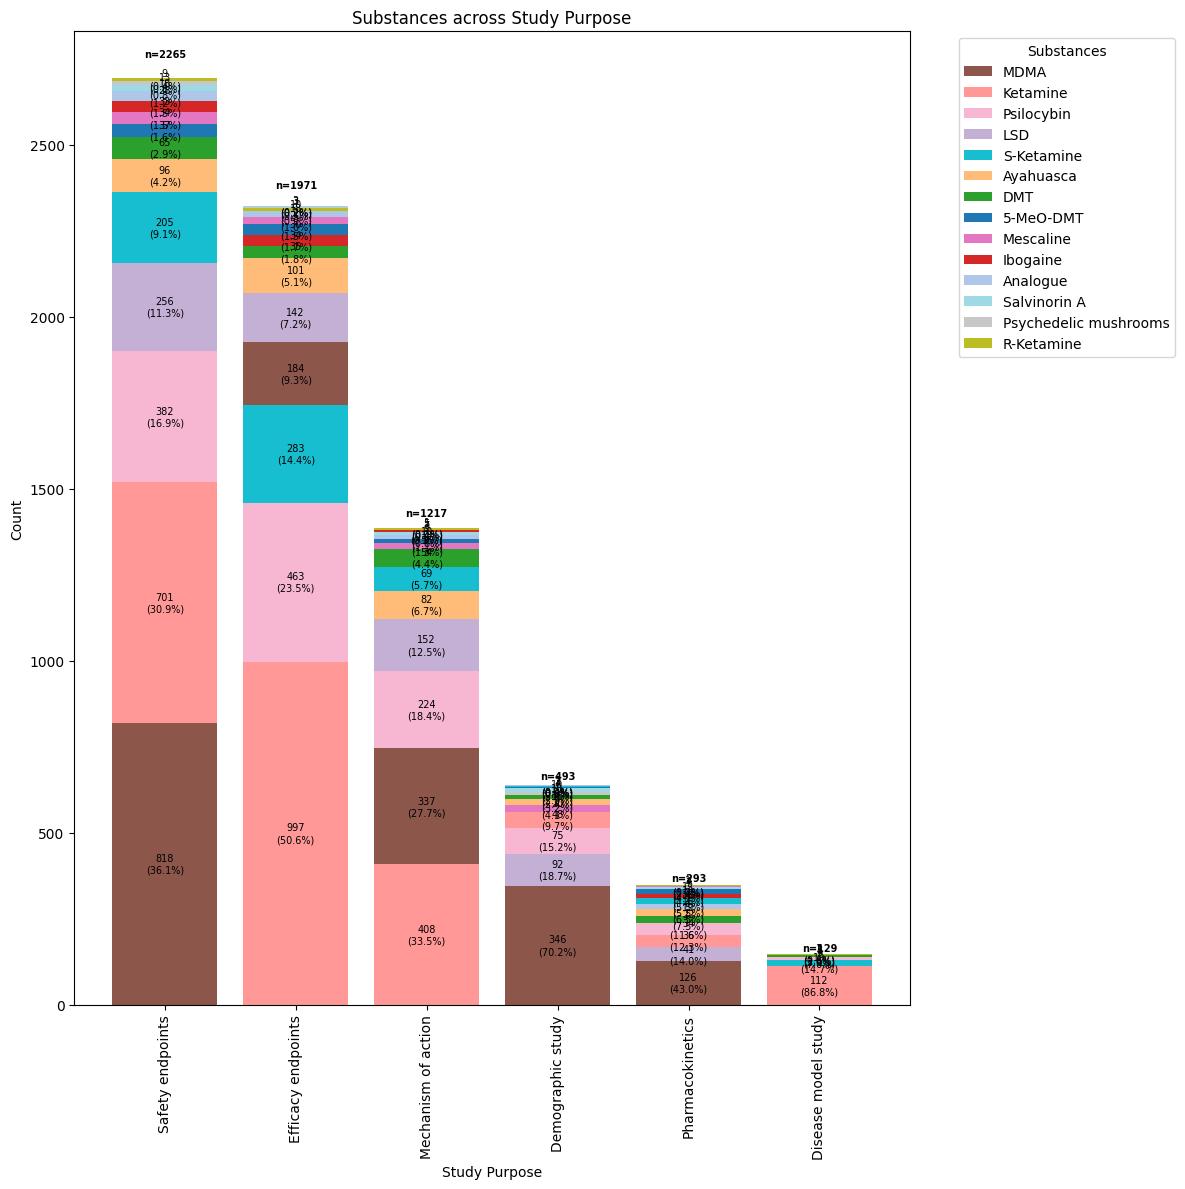

In [116]:
counts = plot_task_stacked_bar(
    df_2025_class,
    x_task="Study Purpose",
    group_task="Substances",
    exclude_labels={
        "Substances": ['Other', 'Unknown', 'Combination Therapy']
    }
)